In [22]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Dropout, TextVectorization, Embedding
from keras.optimizers import AdamW
from keras.losses import SparseCategoricalCrossentropy

import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import string
import re

In [2]:
print(tf.__version__)

2.21.0


In [5]:
ds_zip_path = "/mnt/e/Deep Learning/data/text-classification/6-persian-topics.zip"

with zipfile.ZipFile(ds_zip_path, 'r') as zip_ref:
    zip_ref.extractall(path="/mnt/e/Deep Learning/data")

In [6]:
ds_path = "/mnt/e/Deep Learning/data/6-persian-topics"

classes = os.listdir(ds_path)
classes

['بهداشت و سلامت',
 'جغرافیا و مکانها',
 'دین و اعتقاد',
 'ریاضیات',
 'فناوری و علوم کاربردی و تکنولوژی',
 'ورزش']

In [8]:
batch_size = 32
SEED = 42

train_ds_raw = tf.keras.utils.text_dataset_from_directory(ds_path, 
                                                          batch_size=batch_size,
                                                          seed=SEED,
                                                          validation_split=0.2,
                                                          subset='training'
                                                          )

val_ds_raw = tf.keras.utils.text_dataset_from_directory(ds_path, 
                                                          batch_size=batch_size,
                                                          seed=SEED,
                                                          validation_split=0.2,
                                                          subset='validation'
                                                          )

Found 37573 files belonging to 6 classes.
Using 30059 files for training.
Found 37573 files belonging to 6 classes.
Using 7514 files for validation.


In [ ]:
tf.data.experimental.cardinality(train_ds_raw).numpy()  #Number of batches in training set

np.int64(940)

In [20]:
for texts, labels in train_ds_raw.take(1):
    text_file = texts[0].numpy().decode()
    label = labels[0].numpy()

    print(text_file)
    print(train_ds_raw.class_names[label])

آریزونا (به انگلیسی: Arizona) یکی از ایالت‌های آمریکا است که در منطقه جنوب غرب آمریکا قرار دارد. این ایالت بخشی از منطقه غرب آمریکا و منطقه کوهستانی آمریکا نیز محسوب می‌شود. آریزونا ششمین ایالت بزرگ و شانزدهمین ایالت پرجمعیت آمریکاست. شهر فینیکس پایتخت و پرجمعیت‌ترین شهر آریزونا است.
جغرافیا و مکانها


In [25]:
def custom_standardization(text):
    lower_text = tf.strings.lower(text)
    stripped_html = tf.strings.regex_replace(lower_text, '<br />', ' ')
    stripped_ye = tf.strings.regex_replace(stripped_html, 'ي', 'ی')
    stripped_punc = tf.strings.regex_replace(stripped_ye,
                                  '[%s]' % re.escape(string.punctuation),
                                  '')
    
    return stripped_punc

In [27]:
txt = " براي برای"
print(f"Original Text: {txt}")
print(f"Stripped text: {custom_standardization(txt).numpy().decode()}")

Original Text:  براي برای
Stripped text:  برای برای


In [30]:
max_features = 10000
sequence_length = 250

vectorize_layer = tf.keras.layers.TextVectorization(standardize=custom_standardization,
                                                    max_tokens=max_features,
                                                    output_mode='int',
                                                    output_sequence_length=sequence_length)

In [32]:
vectorize_layer.adapt(train_ds_raw.map(lambda x, y: x))

In [38]:
for texts, labels in train_ds_raw.take(1):
    print(texts.shape)

(32,)


In [40]:
def vectorize_text(text, label):
    text = tf.expand_dims(text, axis=-1)
    vect = vectorize_layer(text)

    return vect, label

In [41]:
train_ds_vect = train_ds_raw.map(vectorize_text)
val_ds_vect = val_ds_raw.map(vectorize_text)

In [43]:
for texts, labels in train_ds_vect.take(1):
    print(texts.shape)
    print(labels)

(32, 250)
tf.Tensor([5 1 4 4 1 0 1 1 4 5 4 4 1 1 1 1 0 1 1 1 1 0 1 1 2 4 4 4 1 1 4 4], shape=(32,), dtype=int32)


In [44]:
train_ds = train_ds_vect.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds_vect.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
import keras.layers as layers

embedding_dim = 16

model = tf.keras.Sequential([
    layers.Input(shape=(250, )),
    layers.Embedding(max_features, embedding_dim),
    layers.GlobalAveragePooling1D(),
    layers.Dense(100),
    layers.Dropout(0.5),
    layers.Dense(len(train_ds_raw.class_names))])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 250, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │         1,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,306 (634.01 KB)

 Trainable params: 162,306 (634.01 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
model.compile(loss=SparseCategoricalCrossentropy(from_logits=True),
              optimizer='adam',
              metrics=['accuracy'])

In [51]:
epochs = 15
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.6987 - loss: 0.8578 - val_accuracy: 0.8854 - val_loss: 0.3951
Epoch 2/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8916 - loss: 0.3311 - val_accuracy: 0.9015 - val_loss: 0.2726
Epoch 3/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9264 - loss: 0.2305 - val_accuracy: 0.9360 - val_loss: 0.1971
Epoch 4/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9440 - loss: 0.1771 - val_accuracy: 0.9458 - val_loss: 0.1630
Epoch 5/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9548 - loss: 0.1433 - val_accuracy: 0.9566 - val_loss: 0.1329
Epoch 6/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9636 - loss: 0.1173 - val_accuracy: 0.9582 - val_loss: 0.1289
Epoch 7/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9700 - loss: 0.0993 - val_accuracy: 0.9587 - val_loss: 0.1287
Epoch 8/15
940/940 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9747 - loss: 0.0847 - val_accuracy: 

In [52]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

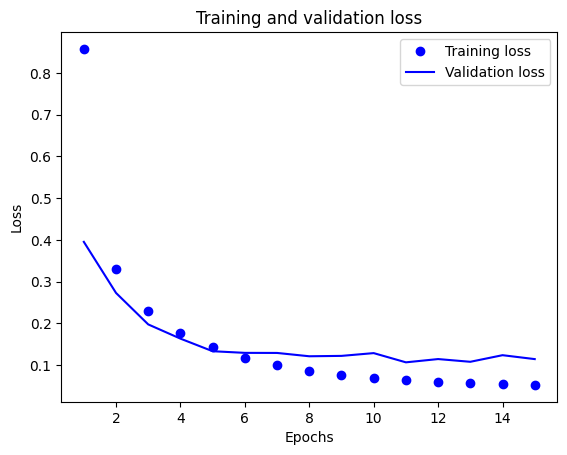

In [53]:
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

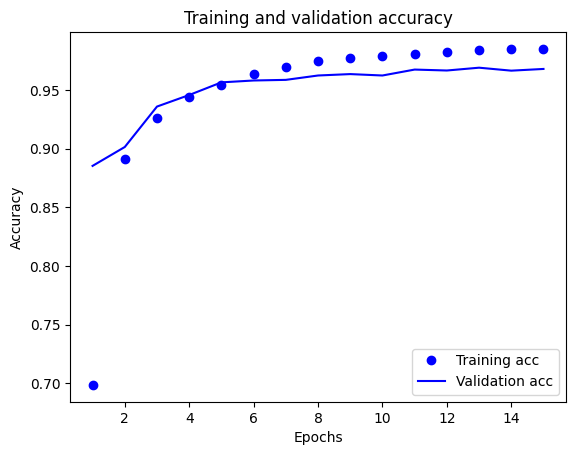

In [54]:
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()